In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from black_scholes.pinn.bs_pinn import BlackScholesPINN
from utility.model import ModelConfig

from black_scholes.tree.tree import BinomialTree
from utility.plot import plot_price_heatmaps

In [2]:
# Parameters

r = 0.1
sigma = 0.3
K = 1.0
T = 1.0
S_min = 0.0
S_max = 3 * K

In [3]:
input_size = 2
hidden_sizes = [32, 32, 32]
output_size = 1
activation = nn.Sigmoid()
learning_rate = 0.001

# Scheduler
step_size = 2000
gamma = 0.7

model_config = ModelConfig(
    input_size=input_size,
    hidden_sizes=hidden_sizes,
    output_size=output_size,
    activation=activation,
    learning_rate=learning_rate,
    step_size=step_size,
    gamma=gamma
)

loss_weights = {
    'variational': 5,
    'terminal': 5,
    'Smax': 3,
    'Smin': 3
}

In [4]:
seeds = [40, 41, 42, 43, 44]

pinns = []

for seed in seeds:
    pinn = BlackScholesPINN(model_config, seed=seed)
    pinn.set_params(K, r, sigma, T, S_min, S_max)
    pinn.set_loss_weights(loss_weights)

    pinn.load(f'../models/bs_pinn_1d/{seed}.pth')
    pinns.append(pinn)

## Compare with binomial Tree

In [5]:
bt = BinomialTree(K, r, T, sigma, n_steps=1000, option_type="put", exercise_type="american")

In [ ]:
pinn = pinns[3]

# grid resolution
num_S = 80
num_T = 80

Ss = np.linspace(S_min, S_max, num_S)
Ts = np.linspace(0, T-1e-4, num_T)  # avoid exactly zero maturity

nn_prices = np.zeros((num_T, num_S))
bt_prices = np.loadtxt('../black_scholes/tree/bt_prices.txt')

for i, t_val in enumerate(Ts):
    t_tensor = torch.full((num_S,), t_val)
    nn_prices[i, :] = pinn.predict(t_tensor, Ss).squeeze().numpy()

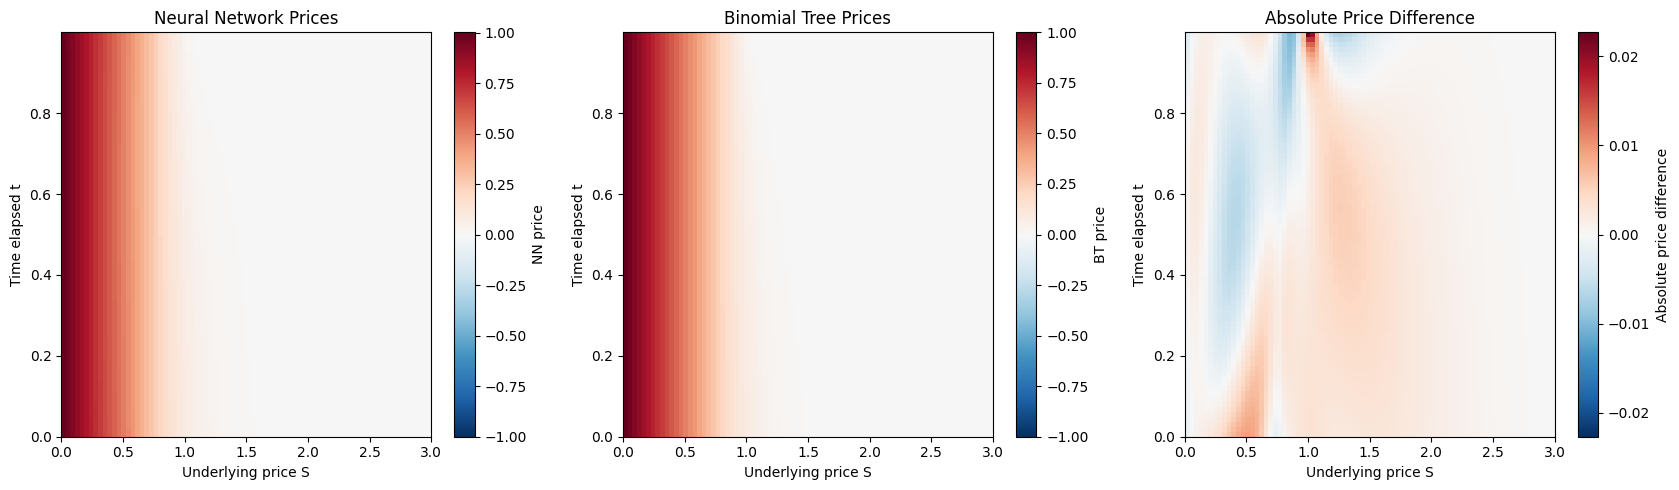

In [17]:
plot_price_heatmaps(
    prices1=nn_prices, prices2=bt_prices,
    xlabel='Underlying price S', ylabel='Time elapsed t',
    title1='Neural Network Prices', title2='Binomial Tree Prices', title_diff='Absolute Price Difference',
    label1='NN price', label2='BT price', label_diff='Absolute price difference',
    extent=[Ss[0], Ss[-1], Ts[0], Ts[-1]]
)

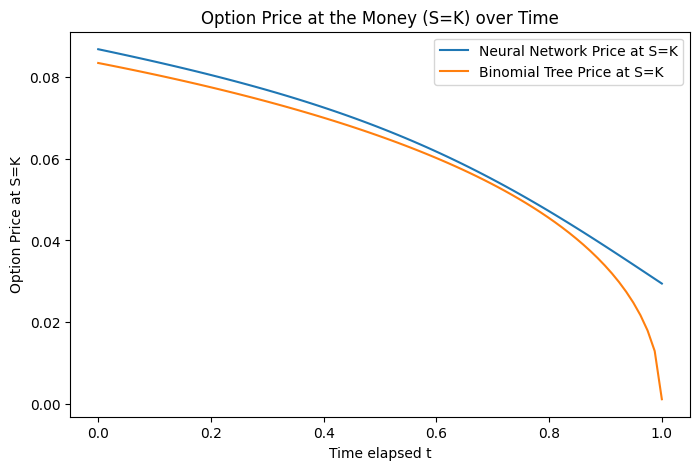

In [18]:
# Error at the money
S_try = K
nn_prices_atm = [pinn.predict(t, S_try).item() for t in Ts]
bt_prices_atm = [bt.predict(t, S_try) for t in Ts]

plt.figure(figsize=(8, 5))
plt.plot(Ts, nn_prices_atm, label='Neural Network Price at S=K')
plt.plot(Ts, bt_prices_atm, label='Binomial Tree Price at S=K')
plt.xlabel('Time elapsed t')
plt.ylabel('Option Price at S=K')
plt.title('Option Price at the Money (S=K) over Time')
plt.legend()
plt.show()